# Generating Images with a Normalizing Flow

In the [normalizing flows session](../sessions/flow.ipynb) we fitted a masked autoregressive flow to a
two-dimensional toy dataset and to the six-dimensional UCI POWER benchmark, and we used it for two things:
evaluating an exact density, and drawing samples.

Here we point the same model at **images**, and use the sampling direction as an image generator.
MNIST digits are 28x28 = 784-dimensional, which is a jump of two orders of magnitude from POWER.

The exercise has two parts, and the second one exists because of what happens in the first:

1. **A flow on raw pixels.** We fit the flow to all 784 pixel dimensions, measure its likelihood in
   *bits per dimension* -- the standard unit for image density models -- and then look at its samples.
2. **A flow on autoencoder codes.** We fit the same kind of flow to the 32-dimensional latent codes of the
   dense autoencoder from the [autoencoders session](../sessions/autoencoders.ipynb), and decode its samples
   back into images.

This is the solution notebook: every cell is filled in, and the discussion after each part is what the
measurements actually showed.

> **Before you start:** part 2 loads the autoencoder trained in the
> [autoencoders session](../sessions/autoencoders.ipynb). Run that notebook first, at least as far as the
> latent-dimension sweep that saves `../data/autoencoder_dense_32_encoder.keras` and
> `../data/autoencoder_dense_32_decoder.keras`. Those checkpoints are not in the repository.

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
from jax import random
import flowjax
import flowjax.bijections
import flowjax.distributions
import flowjax.flows
import flowjax.train
import keras

sns.set(style='white', context='talk')
SEED = 130
rng = np.random.default_rng(SEED)

print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())
print('FlowJAX:', flowjax.__version__)

Keras: 3.15.1 backend: jax gpu
FlowJAX: 19.1.1


## The data

(60000, 28, 28) (10000, 28, 28) uint8 0 255


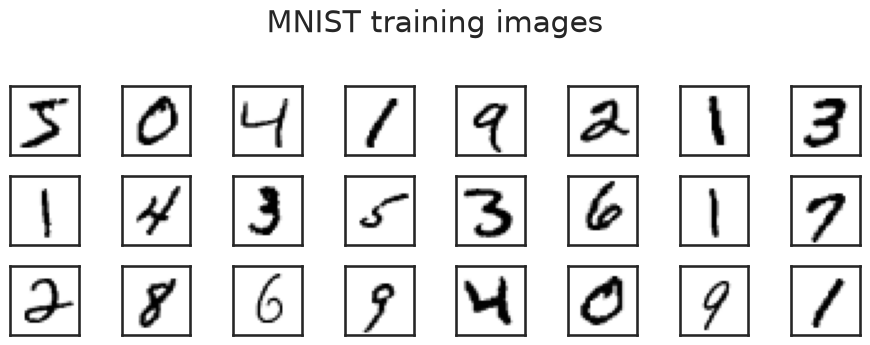

In [2]:
(X_train, Y_train), (X_validation, Y_validation) = keras.datasets.mnist.load_data()
print(X_train.shape, X_validation.shape, X_train.dtype, X_train.min(), X_train.max())

def show_grid(images, title='', n_cols=8):
    """Draw a row-major grid of 28x28 images in [0, 1]."""
    images = np.asarray(images).reshape(-1, 28, 28)
    n_rows = int(np.ceil(len(images) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.15 * n_cols, 1.2 * n_rows))
    for ax, image in zip(axes.ravel(), images):
        ax.imshow(image, cmap='gray_r', vmin=0, vmax=1)
    for ax in axes.ravel():
        ax.set(xticks=[], yticks=[])
    fig.suptitle(title)
    fig.tight_layout()

show_grid(X_train[:24] / 255, title='MNIST training images')

# Part 1: a flow on raw pixels

## Pixels are not POWER: two things have to be fixed first

A flow puts a *continuous* density on $\mathbb{R}^D$. MNIST pixels are neither continuous nor unbounded,
and both facts break the model if we ignore them.

**Pixels are discrete.** Every pixel is an integer in $\{0, \dots, 255\}$, so the data lives on a lattice.
A continuous density can pile arbitrarily tall spikes on a lattice and drive the likelihood to $+\infty$
without learning anything -- exactly the failure the POWER session dequantized away, and much worse here,
because most MNIST pixels are *exactly* 0. So we **dequantize**: add uniform noise of one quantization step,
$$
v = \frac{x + u}{256}, \qquad u \sim U[0, 1)^{784},
$$
which spreads each reported integer over the interval it actually stands for, and puts $v$ in $[0, 1)^{784}$.

**Pixels are bounded.** $v$ lives in the unit cube, and our base distribution is a Gaussian on all of
$\mathbb{R}^{784}$. Squeezing an unbounded density into a cube means piling up mass at the faces.
The standard fix is a **logit transform**, with a small $\alpha$ to keep the transform finite at $v = 0$ and $v = 1$:
$$
y = \operatorname{logit}\big(\alpha + (1 - 2\alpha) v\big), \qquad \alpha = 0.05 .
$$

We fit the flow to $y$. Both steps are invertible with a tractable Jacobian, which is what lets us convert
the flow's likelihood back into a statement about the original images at the end.

(60000, 784) logit range -2.94 .. +2.94


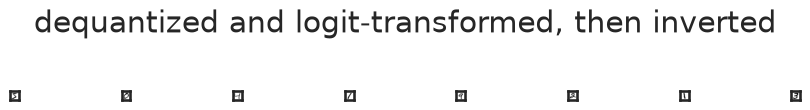

In [3]:
ALPHA = 0.05

def dequantize_logit(images_uint8, rng):
    """uint8 images -> (y, v): logit-space values to model, and the dequantized values in [0, 1)."""
    n = len(images_uint8)
    v = (images_uint8.reshape(n, -1).astype(np.float32) + rng.random((n, 784), dtype=np.float32)) / 256.0
    p = ALPHA + (1 - 2 * ALPHA) * v
    y = np.log(p) - np.log1p(-p)
    return y.astype(np.float32), v

def inverse_logit(y):
    """Back from logit space to pixel intensities in [0, 1], for plotting."""
    p = 1 / (1 + np.exp(-np.asarray(y)))
    return np.clip((p - ALPHA) / (1 - 2 * ALPHA), 0, 1)

Y_train, V_train = dequantize_logit(X_train, rng)
Y_validation, V_validation = dequantize_logit(X_validation, rng)
print(Y_train.shape, f'logit range {Y_train.min():+.2f} .. {Y_train.max():+.2f}')

# The transform is invertible: decoding the logit values reproduces the images.
show_grid(inverse_logit(Y_train[:8]), title='dequantized and logit-transformed, then inverted')

## The flow

This is the POWER flow from the session with one number changed -- the dimension. Same masked autoregressive
structure, same rational-quadratic spline transformer, same `fit_to_data` call.

`interval=6` because the logit transform with $\alpha = 0.05$ maps the data into $\pm 2.95$, and a spline is
pinned to the identity outside its box.

In [4]:
key = random.key(SEED)

key, subkey = random.split(key)
pixel_flow = flowjax.flows.masked_autoregressive_flow(
    subkey,
    base_dist=flowjax.distributions.Normal(jnp.zeros(784)),
    transformer=flowjax.bijections.RationalQuadraticSpline(knots=8, interval=6),
    flow_layers=4,
    nn_width=512,
    nn_depth=2,
)

Training is capped at 20 epochs to keep this to about three minutes on a GPU. That cap is *binding* --
the flow has not converged -- and we come back to what that does and does not excuse.

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:22<?, ?it/s, train=-771, val=-1.22e+3]

  5%|▌         | 1/20 [00:22<06:59, 22.08s/it, train=-771, val=-1.22e+3]

  5%|▌         | 1/20 [00:32<06:59, 22.08s/it, train=-1.26e+3, val=-1.27e+3]

 10%|█         | 2/20 [00:32<04:37, 15.39s/it, train=-1.26e+3, val=-1.27e+3]

...

 95%|█████████▌| 19/20 [03:17<00:10, 10.68s/it, train=-1.47e+3, val=-1.46e+3]

 95%|█████████▌| 19/20 [03:27<00:10, 10.68s/it, train=-1.48e+3, val=-1.46e+3]

100%|██████████| 20/20 [03:28<00:00, 10.75s/it, train=-1.48e+3, val=-1.46e+3]

100%|██████████| 20/20 [03:28<00:00, 10.41s/it, train=-1.48e+3, val=-1.46e+3]


trained for 20 epochs in 210s


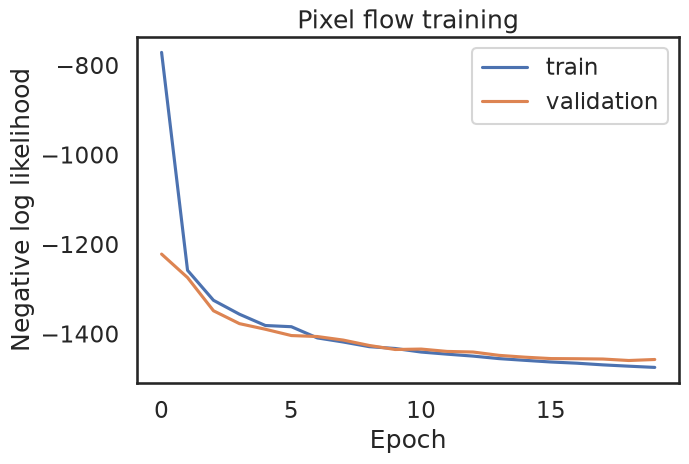

In [5]:
t0 = time.time()
key, subkey = random.split(key)
pixel_flow, pixel_losses = flowjax.train.fit_to_data(
    subkey,
    pixel_flow,
    jnp.asarray(Y_train),
    learning_rate=1e-3,
    batch_size=256,
    max_patience=8,
    max_epochs=20,
    show_progress=True,
)
print(f'\ntrained for {len(pixel_losses["train"])} epochs in {time.time() - t0:.0f}s')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(pixel_losses['train'], label='train')
ax.plot(pixel_losses['val'], label='validation')
ax.set(title='Pixel flow training', xlabel='Epoch', ylabel='Negative log likelihood')
ax.legend();

## How good is the likelihood? Bits per dimension

Nats on the logit-transformed data are not comparable to anything, because the logit transform changed the
units. The unit every image density model reports is **bits per dimension**: the average number of bits needed
to encode one pixel of a held-out image. Lower is better, and 8 bits/dim is what you get by storing the raw
byte.

Getting there is two changes of variables, undoing what we did to the data:

$$
\log p_V(v) = \log p_Y(y) + \sum_{j} \log\left|\frac{\partial y_j}{\partial v_j}\right| ,
\qquad
\frac{\partial y_j}{\partial v_j} = \frac{1 - 2\alpha}{p_j (1 - p_j)} ,
$$

and then from the dequantized $v = (x + u)/256$ back to the discrete image, which contributes $-784 \log 256$:

$$
\text{bits/dim} = -\frac{\mathbb{E}_u[\log p_V(v)] - 784 \log 256}{784 \log 2} .
$$

For reference we also score a baseline that cannot generate anything at all: independent Gaussians, one fitted
per pixel, with no dependence between pixels whatsoever.

In [6]:
def logit_log_jacobian(v):
    """sum_j log |dy_j / dv_j| for the logit transform above."""
    p = ALPHA + (1 - 2 * ALPHA) * v
    return np.sum(np.log(1 - 2 * ALPHA) - np.log(p) - np.log1p(-p), axis=1)

def bits_per_dim(log_prob_y, v):
    log_p_v = log_prob_y + logit_log_jacobian(v)
    return -(log_p_v.mean() - 784 * np.log(256)) / (784 * np.log(2))

# Score in batches: 10,000 images at 784 dimensions at once is a lot of memory.
flow_log_prob = np.concatenate([
    np.asarray(pixel_flow.log_prob(jnp.asarray(Y_validation[i:i + 2000])))
    for i in range(0, len(Y_validation), 2000)
])
print(f'flow:                {bits_per_dim(flow_log_prob, V_validation):.3f} bits/dim')

# Baseline: one independent Gaussian per pixel, fitted in logit space.
mean, std = Y_train.mean(axis=0), Y_train.std(axis=0)
gaussian_log_prob = (-0.5 * ((Y_validation - mean) / std) ** 2 - np.log(std) - 0.5 * np.log(2 * np.pi)).sum(axis=1)
print(f'independent Gaussian: {bits_per_dim(gaussian_log_prob, V_validation):.3f} bits/dim')

flow:                1.322 bits/dim


independent Gaussian: 4.853 bits/dim


## Generating images

The flow is a distribution over logit-space vectors, so generating an image is three steps: sample, invert the
logit transform, reshape to 28x28.

sampled 24 images in 5.7s


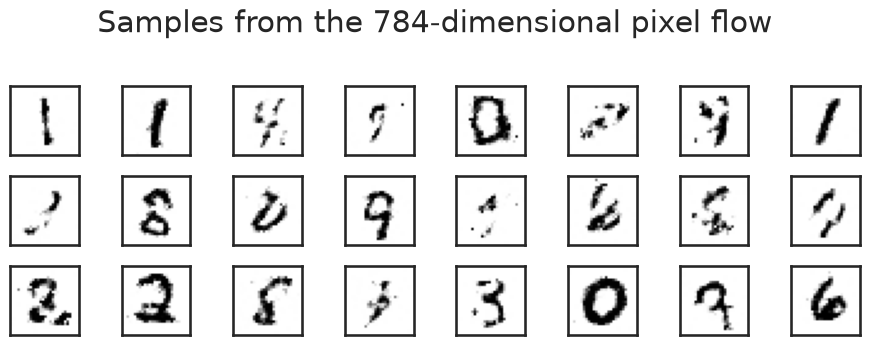

In [7]:
key, subkey = random.split(key)
t0 = time.time()
pixel_samples = np.asarray(pixel_flow.sample(subkey, (24,)))
print(f'sampled 24 images in {time.time() - t0:.1f}s')

show_grid(inverse_logit(pixel_samples), title='Samples from the 784-dimensional pixel flow')

### What the pixel flow learned

Look carefully before deciding whether this worked, because the answer is genuinely mixed. Roughly a third of
the 24 are clean, recognizable digits. Roughly a third are not digits at all -- disconnected fragments, a
scatter of speckle, ink in the shape of nothing. The rest are in between: digit-*like*, with a broken stroke or
a stray blob that no one would write.

Notice what the model *did* get right. The background is clean, the ink is concentrated in the middle of the
frame, the strokes have plausible width and darkness, and the local texture is handwriting. What it gets wrong
is global: whether the strokes join up into one connected figure of a particular kind. It has learned what ink
looks like, not what a digit is.

Sample quality also varies noticeably from run to run -- rerun the sampling cell with a different key and the
proportion of readable digits moves around. That is worth knowing before drawing a conclusion from any single
grid of 24.

**And it is not undertrained.** That is the first objection, and it deserves a measurement rather than an
argument. Trained to convergence instead of the 20-epoch cap -- early stopping fired after 83 epochs, best
epoch 73, about 8 minutes -- this same flow reaches **1.254 bits/dim** against the 1.322 above, and its samples
are no more digit-like; the run-to-run spread above is larger than the difference. Four times the training buys
0.07 bits/dim and no visible improvement. (Measured separately, outside this notebook; question 2 asks you to
reproduce it.)

So we have a model whose held-out likelihood is good -- 1.3 bits/dim is in the range flow papers report for
MNIST, and nearly four times better as a code length than the per-pixel Gaussian's 4.85 -- and which cannot
reliably draw a digit. Hold on to that; question 1 is about exactly this.

# Part 2: a flow on autoencoder codes

Part 1 fitted a density to pixels directly, and pixels are a bad coordinate system to be generative in: 784
strongly dependent dimensions, most of which are background.

The [autoencoders session](../sessions/autoencoders.ipynb) already built a better coordinate system. Its dense
autoencoder compresses an image to a 32-dimensional code and reconstructs it, and reconstructions from those
codes look like digits. What the autoencoder does *not* give you is a way to generate: it has no distribution
over codes, so there is nothing to sample. Feeding the decoder an arbitrary vector gives an arbitrary picture.

That is precisely the missing piece a flow supplies. We fit a density to the codes, sample from it, and decode.

We load the encoder and decoder trained in that session -- 32 dimensions is the largest of the three latent
sizes it sweeps.

latent dimension: 32


(60000, 32) standardized range -5.19 .. +5.33


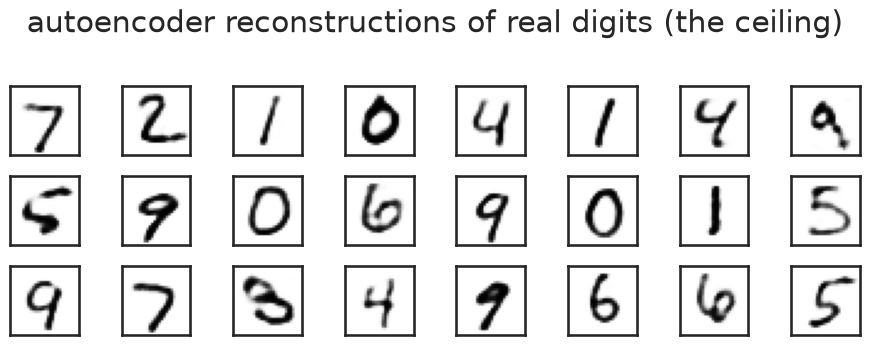

In [8]:
encoder = keras.models.load_model('../data/autoencoder_dense_32_encoder.keras')
decoder = keras.models.load_model('../data/autoencoder_dense_32_decoder.keras')
latent_dim = encoder.output_shape[-1]
print('latent dimension:', latent_dim)

Z_train = encoder.predict(X_train / 255, verbose=0)
Z_validation = encoder.predict(X_validation / 255, verbose=0)

# Standardize the codes. The encoder had no reason to produce anything near N(0, 1),
# and a spline transformer needs its data inside the interval it is defined on.
z_mean, z_std = Z_train.mean(axis=0), Z_train.std(axis=0)
Z_train = ((Z_train - z_mean) / z_std).astype(np.float32)
Z_validation = ((Z_validation - z_mean) / z_std).astype(np.float32)
print(Z_train.shape, f'standardized range {Z_train.min():+.2f} .. {Z_train.max():+.2f}')

# The reconstruction ceiling: the best any code-space generator could possibly look.
show_grid(decoder.predict(Z_validation[:24] * z_std + z_mean, verbose=0),
          title='autoencoder reconstructions of real digits (the ceiling)')

## A flow on the codes

The same flow as POWER, at 32 dimensions instead of 6. Unlike part 1 the epoch cap is not binding here --
early stopping fires on its own well short of 300.

In [9]:
key, subkey = random.split(key)
latent_flow = flowjax.flows.masked_autoregressive_flow(
    subkey,
    base_dist=flowjax.distributions.Normal(jnp.zeros(latent_dim)),
    transformer=flowjax.bijections.RationalQuadraticSpline(knots=8, interval=5),
    flow_layers=8,
    nn_width=128,
    nn_depth=2,
)

t0 = time.time()
key, subkey = random.split(key)
latent_flow, latent_losses = flowjax.train.fit_to_data(
    subkey,
    latent_flow,
    jnp.asarray(Z_train),
    learning_rate=1e-3,
    batch_size=256,
    max_patience=15,
    max_epochs=300,
    show_progress=True,
)
print(f'\ntrained for {len(latent_losses["train"])} epochs in {time.time() - t0:.0f}s, '
      f'best epoch {int(np.argmin(latent_losses["val"]))}')

latent_flow_ll = float(jnp.mean(latent_flow.log_prob(jnp.asarray(Z_validation))))
print(f'flow on codes: {latent_flow_ll:+.2f} nats')

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:09<?, ?it/s, train=31.9, val=26.6]

  0%|          | 1/300 [00:09<47:14,  9.48s/it, train=31.9, val=26.6]

  0%|          | 1/300 [00:11<47:14,  9.48s/it, train=25.2, val=23.9]

  1%|          | 2/300 [00:11<25:14,  5.08s/it, train=25.2, val=23.9]

...

 25%|██▍       | 74/300 [02:17<03:33,  1.06it/s, train=12.7, val=16.3]

 25%|██▍       | 74/300 [02:17<03:33,  1.06it/s, train=12.7, val=16.3 (Max patience reached)]

 25%|██▍       | 74/300 [02:17<07:00,  1.86s/it, train=12.7, val=16.3 (Max patience reached)]


trained for 75 epochs in 138s, best epoch 58


flow on codes: -16.72 nats


## Decoding the samples

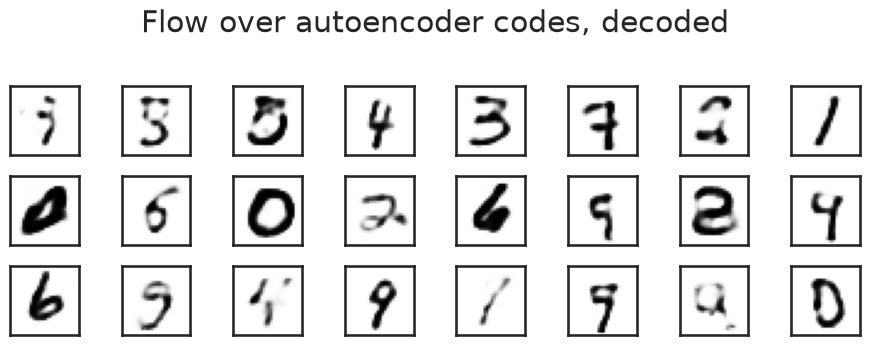

In [10]:
key, subkey = random.split(key)
latent_samples = np.asarray(latent_flow.sample(subkey, (24,)))
flow_images = decoder.predict(latent_samples * z_std + z_mean, verbose=0)

show_grid(flow_images, title='Flow over autoencoder codes, decoded')

Digits -- recognizable, varied, and covering most of the ten classes, from a model that has never
seen a label. A few are malformed, which is what we should expect: the flow occasionally samples a code in a
region the encoder visits rarely, and the decoder has no obligation to make sense of it.

Before concluding anything, run the control.

## The control: is it the decoder or the density?

Two things changed between part 1 and part 2 -- the dimension dropped from 784 to 32, and a trained decoder
appeared at the end of the pipeline. If the decoder is doing the work then any reasonable distribution over
codes would produce digits, and the flow is incidental.

Fit a full-covariance Gaussian to the same codes and decode its samples through the same decoder.

flow on codes:                -16.72 nats
full-covariance Gaussian:     -39.15 nats


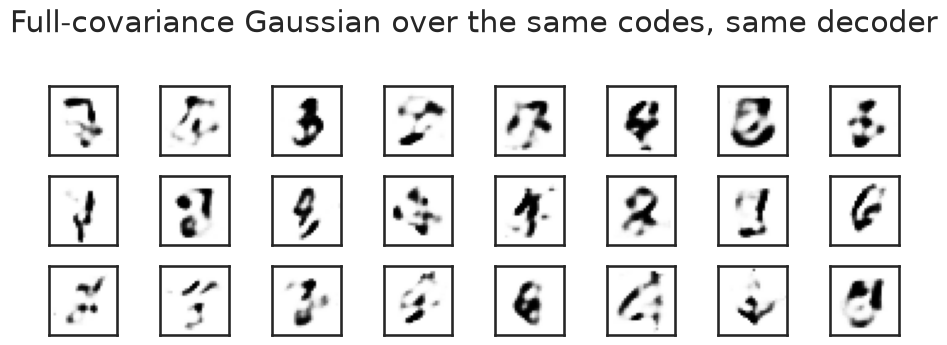

In [11]:
def gaussian_log_likelihood(train, test):
    """Full-covariance Gaussian, as in the POWER section of the session notebook."""
    mean = train.mean(axis=0)
    cov = np.cov(train, rowvar=False)
    _, logdet = np.linalg.slogdet(cov)
    precision = np.linalg.inv(cov)
    delta = test - mean
    quadratic = np.einsum('ij,jk,ik->i', delta, precision, delta)
    return -0.5 * (quadratic + logdet + test.shape[1] * np.log(2 * np.pi))

gaussian_ll = gaussian_log_likelihood(Z_train, Z_validation).mean()

# Sample the same number of codes from that Gaussian and decode them through the same decoder.
gaussian_samples = rng.multivariate_normal(
    Z_train.mean(axis=0), np.cov(Z_train, rowvar=False), size=24).astype(np.float32)
gaussian_images = decoder.predict(gaussian_samples * z_std + z_mean, verbose=0)

print(f'flow on codes:                {latent_flow_ll:+.2f} nats')
print(f'full-covariance Gaussian:     {gaussian_ll:+.2f} nats')
show_grid(gaussian_images, title='Full-covariance Gaussian over the same codes, same decoder')

### What the control shows

Same decoder, same 32 dimensions, same number of samples. The only difference is the distribution the codes
were drawn from, and the pictures are not close: the flow gives mostly digits, the Gaussian gives scribbles
with the *texture* of handwriting and the shape of nothing.

So the decoder is not doing the work. It cannot be -- it is the identical network in both grids. What separates
them is whether the sampled code lands in the part of code space the encoder actually fills, and that is a
statement about the density, which is the flow's job.

The likelihoods say the same thing with one number each: **-16.7 nats for the flow against -39.2 for the
Gaussian**, a gap of 22 nats in 32 dimensions. The codes are not a Gaussian blob -- the encoder was never asked
to make them one -- and a model that assumes they are puts most of its mass in empty space.

Next to the reconstruction ceiling, the ordering is what it should be: reconstructions sharpest, flow samples a
little softer with the occasional malformed digit, Gaussian samples not digits at all.

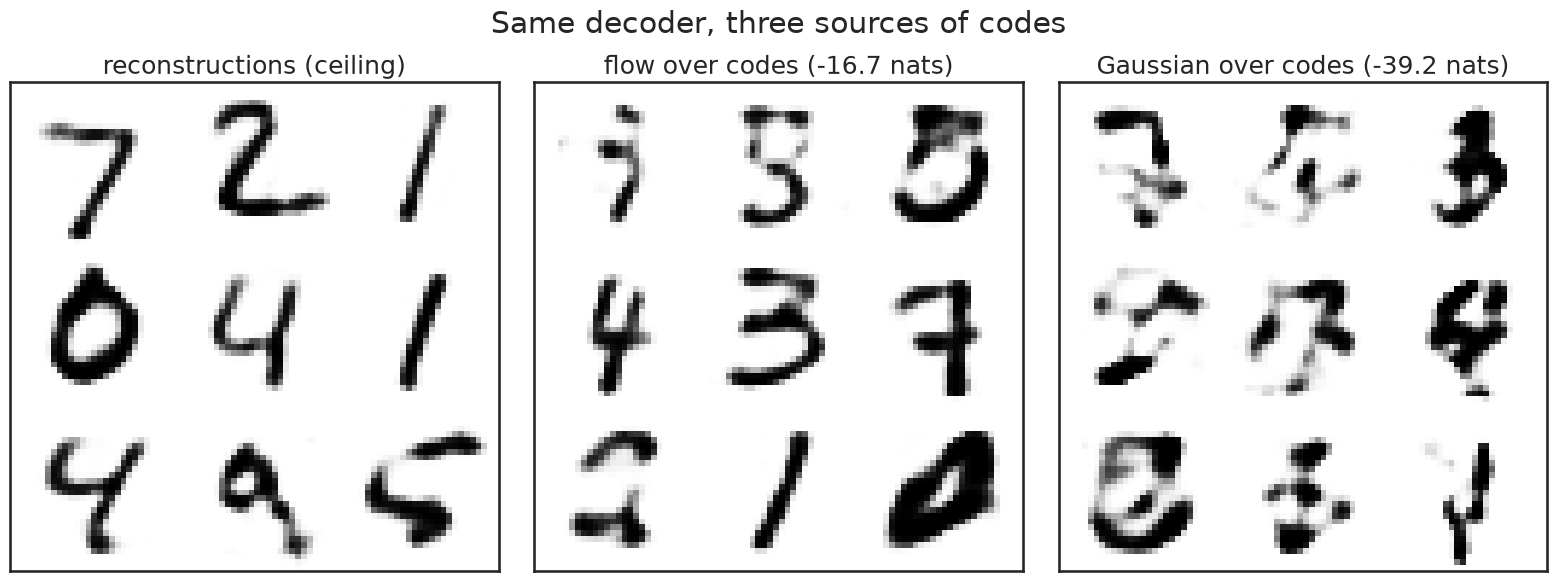

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, images, title in zip(
    axes,
    [decoder.predict(Z_validation[:9] * z_std + z_mean, verbose=0), flow_images[:9], gaussian_images[:9]],
    ['reconstructions (ceiling)', f'flow over codes ({latent_flow_ll:+.1f} nats)',
     f'Gaussian over codes ({gaussian_ll:+.1f} nats)'],
):
    montage = np.asarray(images).reshape(3, 3, 28, 28).transpose(0, 2, 1, 3).reshape(84, 84)
    ax.imshow(montage, cmap='gray_r', vmin=0, vmax=1)
    ax.set(title=title, xticks=[], yticks=[])
fig.suptitle('Same decoder, three sources of codes')
fig.tight_layout()

# Questions

*Answers follow below.*

1. **The central one.** The pixel flow's likelihood is genuinely good -- far better than the per-pixel Gaussian,
   and in the range that published flow papers report for MNIST -- and a large share of its samples are not
   digits. How can a model be right about the density and unreliable about what the data looks like? (Hint: a log-likelihood is an
   average over the *data*. It says how much mass the model puts where the data is. It says nothing about where
   else the model puts mass, and in 784 dimensions there is a great deal of "else".)

2. **Is it just undertrained?** The 20-epoch cap in part 1 is binding. Before blaming it, predict what you would
   expect from training four times longer, then decide what evidence would settle it. (If you have the time:
   raise `max_epochs` to 100 and `max_patience` to 8 and let early stopping fire.)

3. **What did the control show?** Compare the three grids -- flow-over-codes, Gaussian-over-codes, and the
   reconstruction ceiling -- and the two log-likelihoods. Which part of the pipeline is responsible for the good
   samples in part 2, the decoder or the density? How do you know?

4. **Ordering.** A masked autoregressive flow factorizes $p(x) = \prod_j p(x_j \mid x_{<j})$ in a fixed
   coordinate order. For POWER the order of the six columns was arbitrary but harmless. For an image, the
   "order" is raster-scan over pixels. What does conditioning pixel $j$ on all previous pixels in raster order
   mean geometrically, and which pixels that are obviously relevant to $x_j$ end up far away in that ordering?

5. **Bits per dimension.** Our flow is around 1.3 bits/dim; storing the raw byte costs 8. Why is a *density
   model* a lossless compression scheme, and what would 0 bits/dim mean?

# Answers

**1. How can a model be right about the density and wrong about what the data looks like?**

Because a held-out log-likelihood only measures mass *where the data is*. It is an average of $\log p(x)$ over
test points, so it rewards a model for not starving the real digits, and it is completely silent about how much
mass sits everywhere else. In 784 dimensions "everywhere else" is almost all of the space, and the data occupies
a thin, curved, very low-dimensional sliver of it.

Sampling is the other direction, and it sees exactly what the likelihood does not: a sample is drawn from *all*
of the model's mass, including the part spread over regions no digit ever visits. A model can be within a few
percent of optimal on the data and still keep most of its probability in the gaps -- and in high dimensions that
is the typical case rather than a pathology. [Theis et al. (2016)](https://arxiv.org/abs/1511.01844) make this
precise: you can take a good density model, mix it with noise, and lose almost nothing in log-likelihood while
destroying the samples entirely.

The practical reading: **do not accept a likelihood as evidence of sample quality, or bad samples as evidence of
a bad density.** They are close to independent, and each needs its own measurement.

**2. Is it just undertrained?**

No, and the measurement is in part 1: training to convergence (83 epochs against our 20) improves 1.322 to
1.254 bits/dim and leaves the samples no better -- the difference is smaller than the variation between
sampling keys. A 0.07 bits/dim improvement was never going to fix the samples, and it did not.

The thing to notice is what settles the question. "Train longer and see" is a real experiment with a cheap
answer, and the alternative -- reasoning about whether 20 epochs is enough -- is not. The general form of the
mistake is treating a binding cap as an explanation for any result you did not like, instead of spending the
eight minutes it costs to find out.

What is actually wrong is the architecture, not the budget. A masked autoregressive flow over raster-scanned
pixels has no notion of two-dimensional locality; the models that do generate images
([Real NVP](https://arxiv.org/abs/1605.08803), [Glow](https://arxiv.org/abs/1807.03039)) are built out of
convolutional coupling layers over a multi-scale pyramid, which is a different model, not a longer run.

**3. Which part of the pipeline is responsible for the good samples in part 2?**

The density. The control holds the decoder fixed and swaps only the distribution over codes, and the samples
collapse -- so the decoder is necessary but nowhere near sufficient. The 23-nat gap between the flow and the
full-covariance Gaussian on held-out codes is the same fact in likelihood form.

Worth being precise about what part 2 changed relative to part 1, though, because it is two things: the flow
models 32 dimensions instead of 784, *and* those dimensions are a representation trained to make reconstruction
easy. The autoencoder did the hard part -- learning what a digit is -- and left the flow a low-dimensional,
much better-behaved density to fit. Part 2 is not evidence that flows are fine on images after all; it is
evidence that a flow is a good density model in a coordinate system where density modelling is tractable.

**4. Ordering.**

Raster order conditions pixel $j$ on every pixel above it and everything to its left in the same row. The pixel
directly *above* $x_j$ is 28 positions back, which is fine, but the natural neighbourhood of a pixel is a
2D disc and raster order flattens it into a line: the pixel one row below is 28 positions *ahead* and therefore
invisible to the conditioner, and so is everything to the right. Half of each pixel's immediate neighbours are
unavailable by construction, and the ones that are available are reached through a fully-connected MADE that has
to learn from scratch that position $j-28$ means anything special. Convolutional flows get this for free, which
is why they win on images.

**5. Bits per dimension.**

A density model is a compression scheme by the source-coding theorem: a distribution $p$ yields a code that
spends $-\log_2 p(x)$ bits on outcome $x$, and that is optimal when $p$ is the true distribution. So the
model's held-out bits/dim is literally the average code length per pixel you would achieve using it as the
probability model in an arithmetic coder. Storing the raw byte costs 8 bits/dim; our flow gets an MNIST pixel
down to about 1.3.

0 bits/dim would mean the model assigns probability 1 to the images it sees -- no information left to transmit,
because the data is entirely predictable under the model. On held-out data that is unreachable unless the source
is deterministic; approaching it on *training* data is just memorization, which is what the dequantization in
part 1 was there to prevent.

# Further exercises

1. **Fashion-MNIST.** Re-run both parts on `keras.datasets.fashion_mnist`. The images have the same shape, so
   the only thing that changes is the autoencoder -- retrain it with `build_dense_autoencoder` from the
   autoencoders session. Are the pixel-space samples worse than for MNIST, and is the gap between the flow and
   the Gaussian over codes bigger or smaller?

2. **Latent size.** The autoencoders session also saves 2- and 8-dimensional encoders. Fit a flow to each and
   compare the decoded samples. A smaller code is easier to model and reconstructs worse -- where is the best
   trade-off, and how would you measure "best" without looking at the pictures?

3. **Interpolate.** Take two validation images, encode them, and decode a straight line between their codes.
   Then do the same in the flow's *base* space: map both codes to $z$ with `latent_flow.bijection.inverse`,
   interpolate there, and map back with `.transform`. The second path stays in high-density regions and the
   first need not. Do they look different?

4. **Truncation.** Sample the base Gaussian with a standard deviation of 0.7 instead of 1 before pushing it
   through `latent_flow.bijection.transform`, and decode. This is the flow version of the truncation trick used
   in GAN sampling. Sample quality and sample diversity move in opposite directions -- which do you prefer?

5. **A convolutional code.** The autoencoders session also trains a *convolutional* autoencoder. Its codes are
   a feature map rather than a vector; flatten them and fit a flow. Does the better reconstruction ceiling
   translate into better samples?

# References

1. Papamakarios, Pavlakou & Murray (2017), [*Masked Autoregressive Flow for Density Estimation*](https://arxiv.org/abs/1705.07057), NeurIPS. Table 2 reports MNIST in bits/dim, for the *conditional* case.
2. Uria, Murray & Larochelle (2013), [*RNADE: The real-valued neural autoregressive density-estimator*](https://arxiv.org/abs/1306.0186), NeurIPS. Section 3.1 is the standard reference for why discrete data must be dequantized before a continuous density is fitted to it.
3. Theis, van den Oord & Bethge (2016), [*A note on the evaluation of generative models*](https://arxiv.org/abs/1511.01844), ICLR. The paper behind question 1: log-likelihood and sample quality are close to independent in high dimensions, and a model can be excellent at one and useless at the other.
4. Dinh, Sohl-Dickstein & Bengio (2017), [*Density estimation using Real NVP*](https://arxiv.org/abs/1605.08803), ICLR. Where the logit transform of image data used here comes from (Section 4.1), and the multi-scale convolutional architecture that makes pixel-space flows actually generate images.
5. Kingma & Dhariwal (2018), [*Glow: Generative Flow with Invertible 1x1 Convolutions*](https://arxiv.org/abs/1807.03039), NeurIPS. What a flow that really can generate images looks like.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)